In [1]:
from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pyplot as plt
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=10)

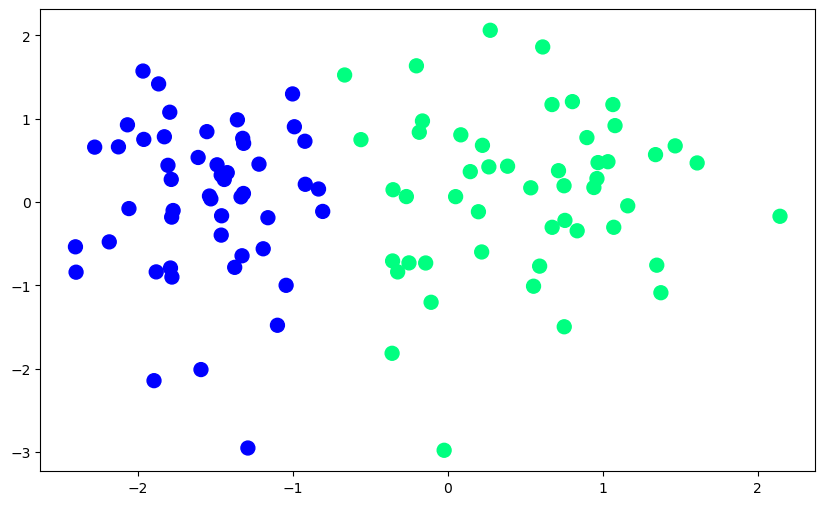

In [2]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

##### Basic math equation behind is as below

If $x_i \in N$ and $\sum w x_i \geq 0$, then:  
$$
w_n = w_0 - \eta x_i
$$

If $x_i \in P$ and $\sum w x_i < 0$, then:  
$$
w_n = w_0 + \eta x_i
$$


𝑥𝑖 ∈N: misclassified negative sample

𝑥𝑖 ∈P: misclassified positive sample

η: learning rate

w: weight vector

𝑤0 : current weights

𝑤𝑛 : updated weights




##### simpified equation, 
 
$
w_n = w_0 + \eta (y_i - \hat{y}_i) x_i
$

Then depending on the value of $(y_i - \hat{y}_i)$:

- If $(y_i - \hat{y}_i) = 0$,  
  $$
  w_n = w_0
  $$

- If $(y_i - \hat{y}_i) = 1$,  
  $$
  w_n = w_0 + \eta x_i
  $$

- If $(y_i - \hat{y}_i) = -1$,  
  $$
  w_n = w_0 - \eta x_i
  $$


In [23]:
def perceptron(X,y):
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    learning_rate = 0.1
    
    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = step_fn(np.dot(X[j],weights))
        weights = weights + learning_rate*(y[j]-y_hat)*X[j]
        
    return weights[0],weights[1:]

In [24]:
def step_fn(z):
    return 1 if z>0 else 0

In [5]:

intercept_,coef_ = perceptron(X,y)

In [6]:
print(coef_)


print(intercept_)

[1.29990268 0.16525531]
1.0


These expressions often come from converting the general line equation:

$
Ax + By + C = 0
$

to the slope-intercept form \( y = mx + c \), by solving for \( y \). This gives us:

$
m = -\frac{A}{B}
$

$
c = -\frac{C}{B}
$


In [7]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [8]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

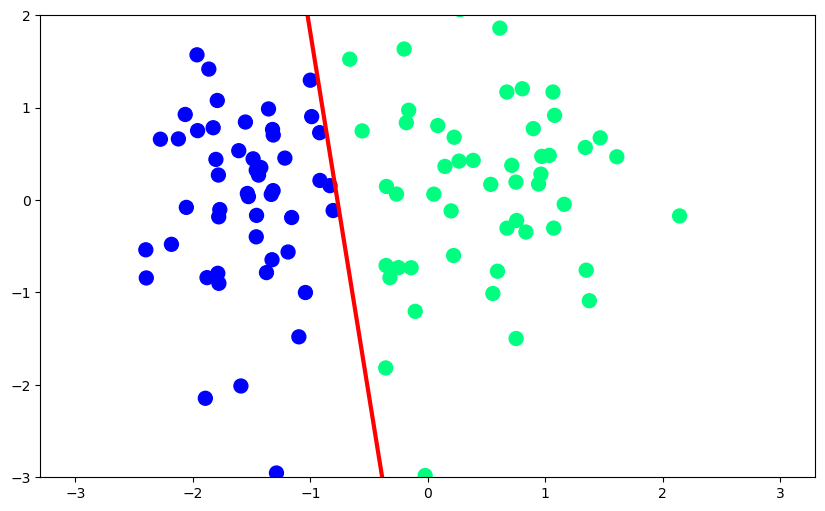

In [9]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

In [10]:
def perceptron(X,y):
    
    m = []
    b = []
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(200):
        j = np.random.randint(0,100)
        y_hat = step_fn(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
        m.append(-(weights[1]/weights[2]))
        b.append(-(weights[0]/weights[2]))
        
    return m,b

In [11]:

m,b = perceptron(X,y)

In [12]:

%matplotlib notebook
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

In [13]:
fig, ax = plt.subplots(figsize=(9,5))

x_i = np.arange(-3, 3, 0.1)
y_i = x_i*m[0] +b[0]
ax.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
line, = ax.plot(x_i, x_i*m[0] +b[0] , 'r-', linewidth=2)
plt.ylim(-3,3)
def update(i):
    label = 'epoch {0}'.format(i + 1)
    line.set_ydata(x_i*m[i] + b[i])
    ax.set_xlabel(label)
    # return line, ax

anim = FuncAnimation(fig, update, repeat=True, frames=200, interval=100)
anim.save('perceptron_anim.mp4')

<IPython.core.display.Javascript object>

In [14]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression()
lor.fit(X,y)

LogisticRegression()

In [15]:
m = -(lor.coef_[0][0]/lor.coef_[0][1])
b = -(lor.intercept_/lor.coef_[0][1])

In [16]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input + b

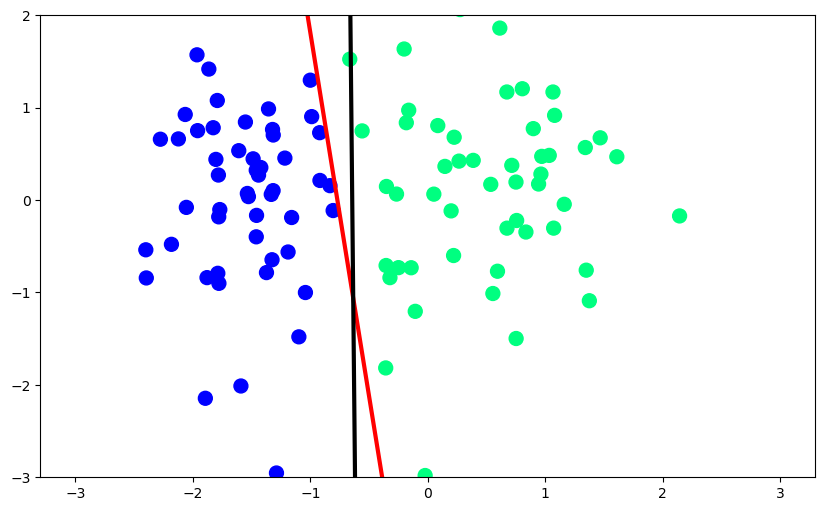

In [22]:
%matplotlib inline
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)
plt.show();

- Here comes the problem with the approach we are following as shown in above code and images. 
- When there is gap between two classes then it is problem with perceptron approach.
- When it sort all the inputs it start changing the line and stop learning and improving.
- And in sklearn class as shown in above it keep improving even though all points are correctly seperated.
- change "class_sep" parameter and obeserve the results.

###

- The approach was to check any random point if it is claffied properly and then apply the above perceptron math.
- But there is a issue, and to resolve the we change our approach.
- Till now we are considering point which are not classified properly but instead we will start considering the point which are classified properly and when any random point like that occures then it start pushing the line away from the points.
- Because of pushing from both the ends, the line will come in the center most probably.